Part 1: Support Vector Machine I

In [1]:
# ─────────────────────────────────────────────────────────
# BLOCK 1: Imports and create a 2D classification dataset
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix)

np.random.seed(42)

# 2 features (so we can plot), 2 classes, slight overlap
X, y = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    class_sep=1.2, random_state=42
)

# ── SVM needs labels as -1 and +1 (not 0 and 1) ──
# This is because the hinge loss uses y·(w·x + b)
y = np.where(y == 0, -1, 1)

# ── Train/test split (80/20) ──
idx = np.random.permutation(200)
n_tr = 160
X_train, y_train = X[idx[:n_tr]], y[idx[:n_tr]]
X_test,  y_test  = X[idx[n_tr:]], y[idx[n_tr:]]

# ── Standardize features (important for SGD) ──
mu, sd = X_train.mean(0), X_train.std(0)
X_train = (X_train - mu) / sd
X_test  = (X_test  - mu) / sd

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))
print("Classes:", np.unique(y))

Training samples: 160
Testing  samples: 40
Classes: [-1  1]


In [2]:
# ─────────────────────────────────────────────────────────
# BLOCK 2: Train Linear SVM using Stochastic Gradient Descent
# ─────────────────────────────────────────────────────────

def train_svm(X, y, C, learning_rate=0.001, epochs=1000):
    """
    Linear SVM via SGD with hinge loss.

    Objective: (1/2)||w||² + C · Σ max(0, 1 - yᵢ(w·xᵢ + b))

    For each sample, check the margin = yᵢ·(w·xᵢ + b):
      - If margin >= 1: point is correctly classified & outside
        the margin → only shrink w (regularization).
      - If margin <  1: point violates the margin → push w and b
        to fix it.

    C controls the trade-off:
      - Large C → punish mistakes heavily → tight fit (less regularization)
      - Small C → allow more mistakes → wider margin (more regularization)
    """
    m, p = X.shape
    w = np.zeros(p)
    b = 0.0

    for _ in range(epochs):
        for i in range(m):
            margin = y[i] * (X[i] @ w + b)

            if margin < 1:
                # Margin violated → update both w and b
                w = w - learning_rate * (w - C * y[i] * X[i])
                b = b + learning_rate * (C * y[i])
            else:
                # Margin satisfied → just shrink w (regularization)
                w = w - learning_rate * w

    return w, b

# Train with C=1 as our main model
w, b = train_svm(X_train, y_train, C=1.0)

print("Learned weight vector w =", w.round(4))
print("Learned bias        b =", round(b, 4))
print("\nThe decision boundary is the line: w·x + b = 0")

Learned weight vector w = [0.5729 0.0129]
Learned bias        b = 0.035

The decision boundary is the line: w·x + b = 0


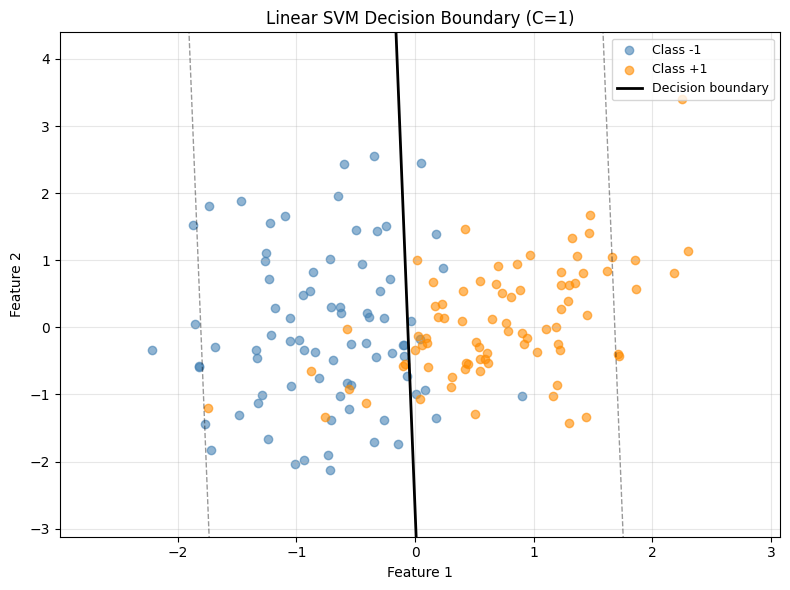

In [4]:
# ─────────────────────────────────────────────────────────
# BLOCK 3: Plot data points + decision boundary
# ─────────────────────────────────────────────────────────

def plot_boundary(X, y, w, b, title, ax=None):
    """Draw the data points and the SVM decision line."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the two classes in different colours
    ax.scatter(X[y==-1, 0], X[y==-1, 1], color='steelblue', alpha=0.6, label='Class -1')
    ax.scatter(X[y== 1, 0], X[y== 1, 1], color='darkorange', alpha=0.6, label='Class +1')

    # Decision boundary: w0·x0 + w1·x1 + b = 0
    # Solve for x1:  x1 = -(w0·x0 + b) / w1
    x0_range = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100)
    if abs(w[1]) > 1e-6:
        x1_boundary = -(w[0]*x0_range + b) / w[1]
        ax.plot(x0_range, x1_boundary, 'k-', linewidth=2, label='Decision boundary')

        # The margins (dashed lines at distance 1)
        x1_margin_up = -(w[0]*x0_range + b - 1) / w[1]
        x1_margin_dn = -(w[0]*x0_range + b + 1) / w[1]
        ax.plot(x0_range, x1_margin_up, 'k--', alpha=0.4, linewidth=1)
        ax.plot(x0_range, x1_margin_dn, 'k--', alpha=0.4, linewidth=1)

    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
    ax.grid(True, alpha=0.3)

plot_boundary(X_train, y_train, w, b, 'Linear SVM Decision Boundary (C=1)')
plt.tight_layout()
plt.show()

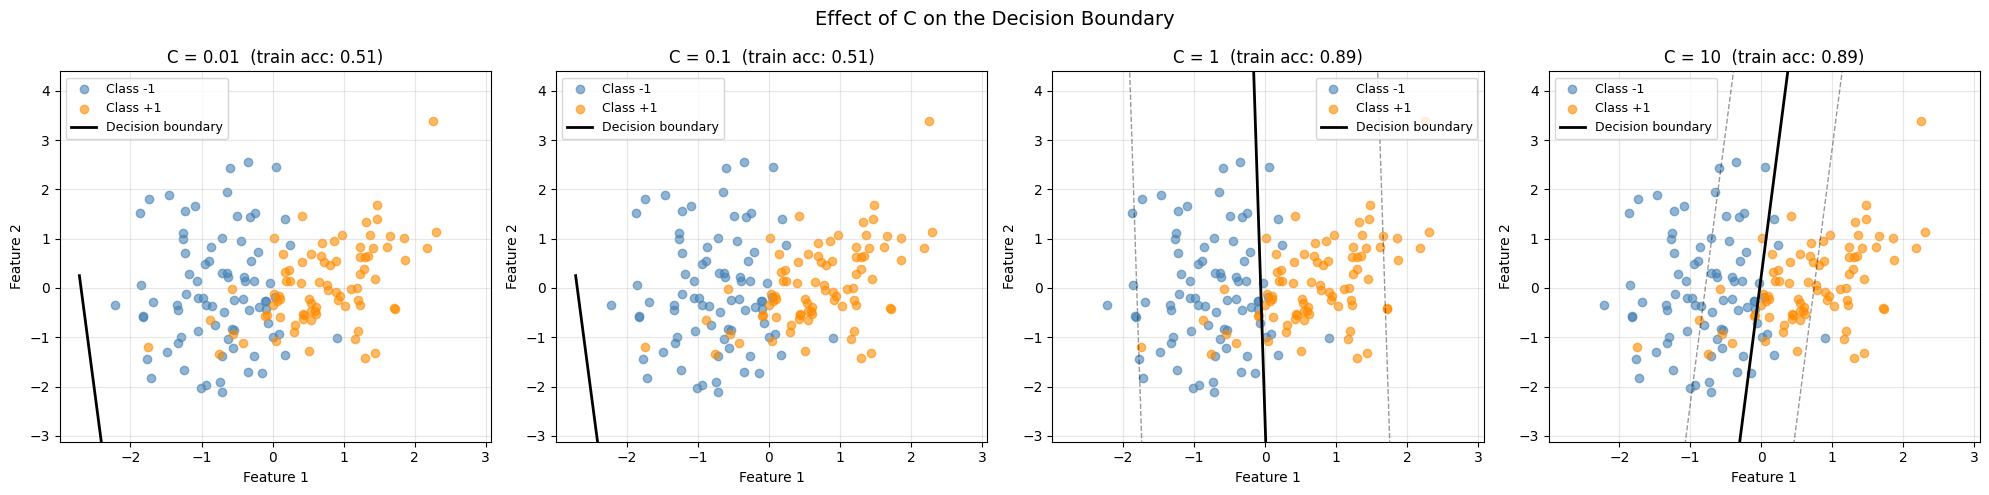


EFFECT OF C:
─────────────────────────────────────────────────────────────
Small C (0.01, 0.1): Strong regularization. The weights stay tiny,
   giving a WIDE margin but allowing many misclassifications.
   On separable data this can UNDERFIT (poor boundary).

Large C (10): Weak regularization. Punishes every misclassification
   heavily, giving a NARROW margin that fits the training data
   tightly. Risk of OVERFITTING on noisy data.

C = 1 is usually a good balanced default.
─────────────────────────────────────────────────────────────



In [5]:
# ─────────────────────────────────────────────────────────
# BLOCK 4: Train SVMs for different C values
# ─────────────────────────────────────────────────────────

C_values = [0.01, 0.1, 1, 10]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, C in zip(axes, C_values):
    w_c, b_c = train_svm(X_train, y_train, C=C)
    acc = np.mean(np.sign(X_train @ w_c + b_c) == y_train)
    plot_boundary(X_train, y_train, w_c, b_c,
                  f'C = {C}  (train acc: {acc:.2f})', ax=ax)

plt.suptitle('Effect of C on the Decision Boundary', fontsize=14)
plt.tight_layout()
plt.show()

print("""
EFFECT OF C:
─────────────────────────────────────────────────────────────
Small C (0.01, 0.1): Strong regularization. The weights stay tiny,
   giving a WIDE margin but allowing many misclassifications.
   On separable data this can UNDERFIT (poor boundary).

Large C (10): Weak regularization. Punishes every misclassification
   heavily, giving a NARROW margin that fits the training data
   tightly. Risk of OVERFITTING on noisy data.

C = 1 is usually a good balanced default.
─────────────────────────────────────────────────────────────
""")

TEST SET PERFORMANCE (C=1)
-----------------------------------
Accuracy : 0.9000
Precision: 0.9412
Recall   : 0.8421


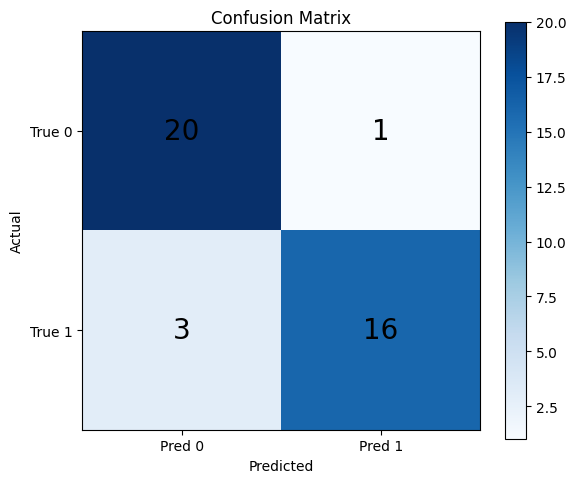


Confusion matrix layout:
  [True Negatives, False Positives]
  [False Negatives, True Positives]


In [6]:
# ─────────────────────────────────────────────────────────
# BLOCK 5: Evaluate the C=1 model on the test set
# ─────────────────────────────────────────────────────────

# Predict on test set
test_predictions = np.sign(X_test @ w + b)

# Convert -1/+1 back to 0/1 for the metric functions
y_test_01 = np.where(y_test == -1, 0, 1)
pred_01   = np.where(test_predictions == -1, 0, 1)

# ── Compute metrics ──
acc  = accuracy_score(y_test_01, pred_01)
prec = precision_score(y_test_01, pred_01)
rec  = recall_score(y_test_01, pred_01)

print("TEST SET PERFORMANCE (C=1)")
print("-" * 35)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")

# ── Confusion matrix ──
cm = confusion_matrix(y_test_01, pred_01)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Pred 0', 'Pred 1'])
plt.yticks([0, 1], ['True 0', 'True 1'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Write the number inside each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=20, color='black')

plt.tight_layout()
plt.show()

print("\nConfusion matrix layout:")
print("  [True Negatives, False Positives]")
print("  [False Negatives, True Positives]")

Part 2: SVM II [Bonus Question - Optional]

           Model  Train Acc  Test Acc  Time (s)
Scratch (Linear)      0.894     0.900    2.3862
  sklearn Linear      0.894     0.900    0.0075
     sklearn RBF      0.894     0.925    0.0022


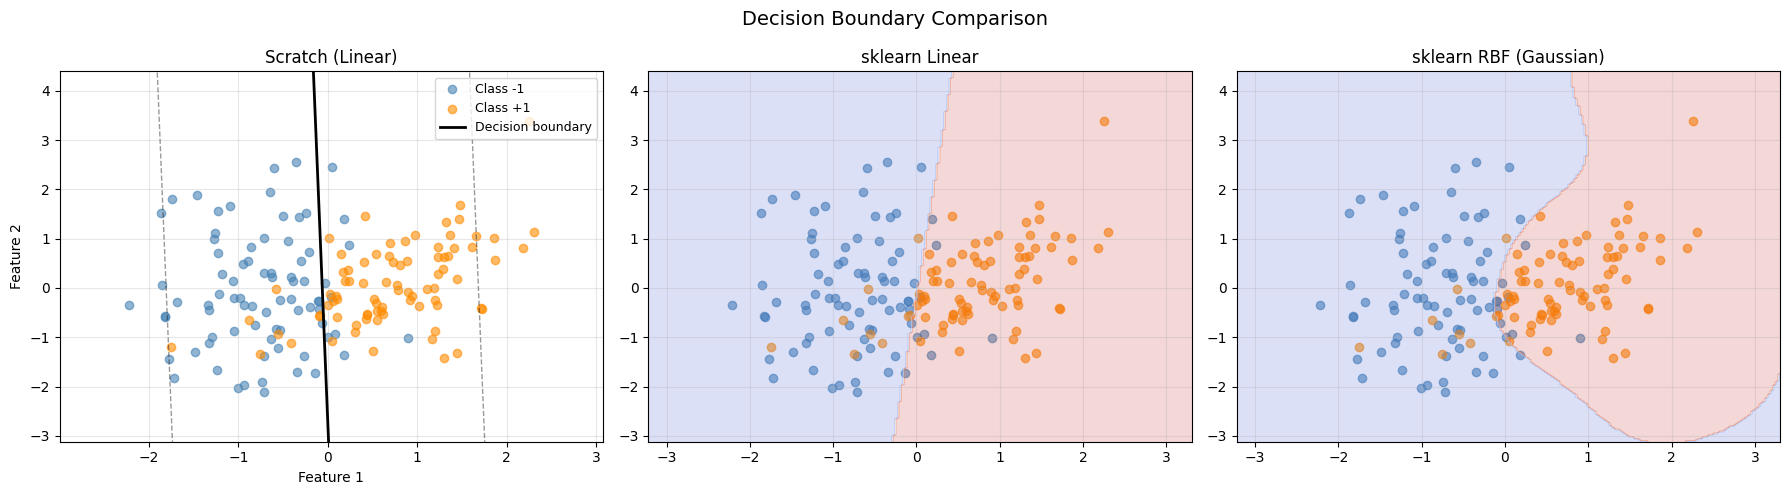


COMPARISON ANALYSIS:
─────────────────────────────────────────────────────────────
- ACCURACY: All three reach similar accuracy on this near-linear
  data. RBF may be slightly higher because it can curve the
  boundary, but on linearly-separable data the gain is small.

- TRAINING TIME: sklearn is dramatically faster (milliseconds)
  than our scratch loop (which loops over every sample, every
  epoch in pure Python). sklearn uses optimized C code under
  the hood.

- DECISION BOUNDARY: Scratch and sklearn-Linear both produce a
  STRAIGHT line. The RBF kernel produces a CURVED boundary
  because it maps data into a higher-dimensional space — useful
  when classes are NOT linearly separable.

TAKEAWAY: Implementing from scratch teaches you the mechanics,
but production code should use the library — it's faster, more
numerically stable, and offers kernels like RBF for free.
─────────────────────────────────────────────────────────────



In [7]:
# ─────────────────────────────────────────────────────────
# BLOCK 6: Compare scratch SVM with sklearn (Linear + RBF)
# ─────────────────────────────────────────────────────────

import time
from sklearn.svm import SVC

# ── 1. Our scratch SVM (time it) ──
start = time.time()
w_scratch, b_scratch = train_svm(X_train, y_train, C=1.0)
time_scratch = time.time() - start

acc_scratch_train = np.mean(np.sign(X_train @ w_scratch + b_scratch) == y_train)
acc_scratch_test  = np.mean(np.sign(X_test  @ w_scratch + b_scratch) == y_test)

# ── 2. sklearn Linear SVM ──
start = time.time()
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
time_linear = time.time() - start

acc_linear_train = svm_linear.score(X_train, y_train)
acc_linear_test  = svm_linear.score(X_test, y_test)

# ── 3. sklearn RBF (Gaussian) SVM ──
start = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0)
svm_rbf.fit(X_train, y_train)
time_rbf = time.time() - start

acc_rbf_train = svm_rbf.score(X_train, y_train)
acc_rbf_test  = svm_rbf.score(X_test, y_test)

# ── Comparison table ──
import pandas as pd
comparison = pd.DataFrame({
    'Model': ['Scratch (Linear)', 'sklearn Linear', 'sklearn RBF'],
    'Train Acc': [round(acc_scratch_train,3), round(acc_linear_train,3), round(acc_rbf_train,3)],
    'Test Acc':  [round(acc_scratch_test,3),  round(acc_linear_test,3),  round(acc_rbf_test,3)],
    'Time (s)':  [round(time_scratch,4), round(time_linear,4), round(time_rbf,4)]
})
print(comparison.to_string(index=False))

# ── Plot all three decision boundaries ──
def plot_sklearn_boundary(model, X, y, title, ax):
    ax.scatter(X[y==-1,0], X[y==-1,1], color='steelblue', alpha=0.6)
    ax.scatter(X[y== 1,0], X[y== 1,1], color='darkorange', alpha=0.6)
    # Create a grid and predict over it to show the boundary region
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    ax.set_title(title); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scratch boundary (line)
plot_boundary(X_train, y_train, w_scratch, b_scratch, 'Scratch (Linear)', ax=axes[0])
# sklearn linear and rbf
plot_sklearn_boundary(svm_linear, X_train, y_train, 'sklearn Linear', axes[1])
plot_sklearn_boundary(svm_rbf, X_train, y_train, 'sklearn RBF (Gaussian)', axes[2])

plt.suptitle('Decision Boundary Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print("""
COMPARISON ANALYSIS:
─────────────────────────────────────────────────────────────
- ACCURACY: All three reach similar accuracy on this near-linear
  data. RBF may be slightly higher because it can curve the
  boundary, but on linearly-separable data the gain is small.

- TRAINING TIME: sklearn is dramatically faster (milliseconds)
  than our scratch loop (which loops over every sample, every
  epoch in pure Python). sklearn uses optimized C code under
  the hood.

- DECISION BOUNDARY: Scratch and sklearn-Linear both produce a
  STRAIGHT line. The RBF kernel produces a CURVED boundary
  because it maps data into a higher-dimensional space — useful
  when classes are NOT linearly separable.

TAKEAWAY: Implementing from scratch teaches you the mechanics,
but production code should use the library — it's faster, more
numerically stable, and offers kernels like RBF for free.
─────────────────────────────────────────────────────────────
""")